In [1]:
%matplotlib widget
from skimage import io
import numpy as np
import matplotlib.pyplot as plt
import torch
import os
from torch import nn
import torch.nn.functional as F
import time
import shutil
from DS3Dplus.ds3d_utils import Sampling
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from datetime import datetime
from torch.optim import Adam
from DS3Dplus.ds3d_utils import MyDataset, KDE_loss3D
from DS3Dplus.ds3d_utils import LON as Net
from DS3Dplus.training_utils import TorchTrainer
from math import pi
import torch.fft as fft
import pickle
from DS3Dplus.lens_utils import LensModelTraining, LensModelBase

from misc import show_imset

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# load imaging model

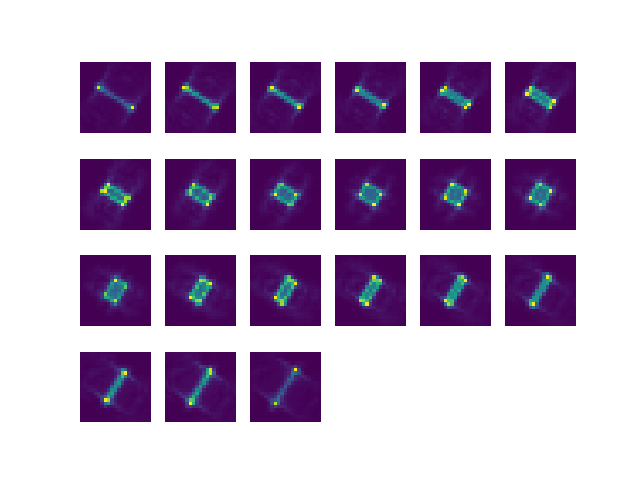

In [2]:
model_dict_file = os.path.join(os.getcwd(), "data", "model_dict_tp16_0126.npy")
psf_param_dict = np.load(model_dict_file, allow_pickle=True).item()

psf_param_dict['device'] = device
model = LensModelBase(psf_param_dict)

num_z = 21
xyzps_test = torch.zeros((num_z, 4), device=device)
xyzps_test[:, 2] = torch.linspace(-11.5, 11.5, num_z, device=device)
xyzps_test[:, 3] = torch.ones((num_z, ), device=device) * 1e3

psfs_test = model(xyzps_test)

show_imset(psfs_test.cpu())

# background subtraction
take every [group size] consecutive frames<br> 
minimum z-projection along the frame axis<br>
subtract each frame by the minimum map<br>

In [3]:
###!!!!!! spacify image folder and saving folder
im_folder = os.path.join(os.getcwd(), "data", "tank16")
save_folder = im_folder
group_size = 500
###!!!!!!

In [4]:
if not os.path.exists(save_folder):
    os.makedirs(save_folder)
    im_files = sorted(os.listdir(im_folder))  # make sure the names are sortable
    n_ims = len(im_files)
    
    group_size = min(group_size, n_ims)
    
    pointer = 0
    for i in range(n_ims//group_size):
        im_names = [im_files[pointer+j] for j in range(group_size)]
        im_stack = [io.imread(os.path.join(im_folder, im_files[pointer+j])) for j in range(group_size)]
        pointer += group_size
        im_stack = np.array(im_stack)
        im_stack = im_stack-np.min(im_stack, axis=0)

        for j in range(group_size):  # save
            io.imsave(os.path.join(save_folder, im_names[j]), im_stack[j], check_contrast=False)
    
    if (n_ims % group_size) != 0:
        # remainder of n_ims/num
        im_stack = [io.imread(os.path.join(im_folder, im_files[-j])) for j in range(group_size)]
        im_stack = np.array(im_stack)
        im_min = np.min(im_stack, axis=0)
        for j in range(pointer, n_ims):
            im = io.imread(os.path.join(im_folder, im_files[j]))
            im = im-im_min
            io.imsave(os.path.join(save_folder, im_files[j]), im, check_contrast=False)
    
    print('Background subtraction is done.')
else:
    print('probably has been done.')
    # shutil.rmtree(save_folder)


probably has been done.


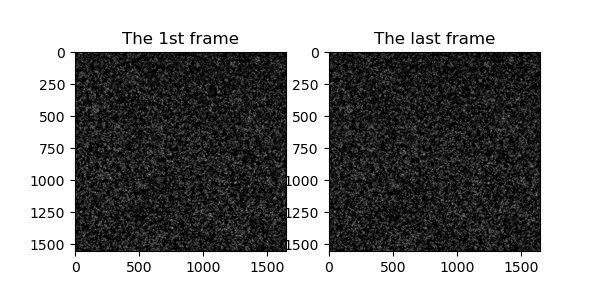

In [5]:
# show images after background subtraction
im_files = sorted(os.listdir(save_folder))
im1 = io.imread(os.path.join(save_folder, im_files[0]))[200:-200, 200:-200]
im_1 = io.imread(os.path.join(save_folder, im_files[-1]))[200:-200, 200:-200]
plt.figure(figsize=(6, 3))
plt.subplot(121)
plt.imshow(im1, cmap='gray')
plt.title('The 1st frame')
plt.subplot(122)
plt.imshow(im_1, cmap='gray')
plt.title('The last frame')
plt.show()

# training data generation
1, specify NFP and z-range to include reasonable PSF shape range<br>
2, SNR tuning by comparing a simulated training image to an experimental image<br>
3, generate training images

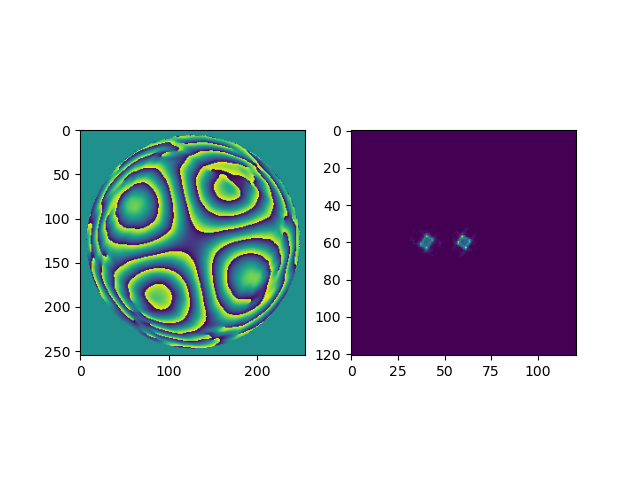

In [6]:
# test the imaging model

param_dict = dict(
    device=device,
    im_size=(121, 121),
    sigma_range= (0.1, 0.5),
    baseline=(0, 1), # d0
    read_std=(0, 1),
    bit_depth = 8,
    ps_camera = 1,  # the lens model is based on unit pixel size, so keep don't change this
    M = 1,
)
param_dict = {**psf_param_dict, **param_dict}

model = LensModelTraining(param_dict)
xyzps = torch.tensor([[0, 0, -0.5, 1e3], [-20, 0, 2.0, 1e3]], device=device)
# xyzps = torch.tensor([[-20, 0, 0.0, 1e3]], device=device)
im = model(xyzps).astype(np.uint8)
plt.figure()
plt.subplot(121)
plt.imshow(psf_param_dict['phase_mask'])
plt.subplot(122)
plt.imshow(im)
plt.show()

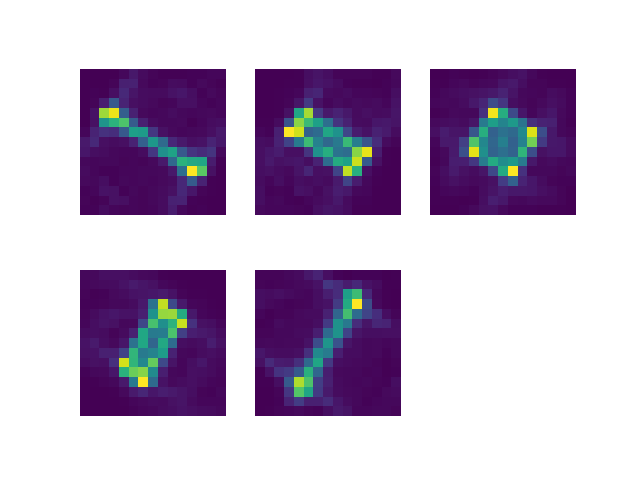

In [7]:
# generate z stack
from DS3Dplus.lens_utils import LensModelBase
from misc import show_imset
from misc import circular_aper

psf_model = LensModelBase(param_dict)

# psf_model.phase_mask = psf_model.phase_mask*0
# psf_model.aper = torch.tensor(circular_aper(psf_model.N, 0.27), device=device)

xyzps = torch.zeros((5, 4), device=device)
xyzps[:, 2] = torch.linspace(-10, 10, 5, device=device)
xyzps[:, 3] = 1e3
psfs = psf_model.get_psfs(xyzps).cpu().numpy()[:, 53:-53, 53:-53]

show_imset(psfs)
# np.save('zstack.npy', psfs)

In [9]:
# psf_row = np.concatenate([psfs[i] for i in range(psfs.shape[0])], axis=1)
# plt.figure()
# plt.imshow(psf_row, cmap='gray')
# # plt.imshow(psf_row, vmax=300.0, cmap='gray')
# plt.axis('off')

# plt.show()

In [10]:
###!!!!!! specify training data parameters
td_folder = os.path.join(os.getcwd(), "training_data", "tank16")

td_param_dict = dict(
    us_factor=2, # up-sampling factor, you may want to have finer xy voxel size
    zrange = (-11.5, 11.5),
    D=115,  # voxel number in the specified z range
    
    # SNR
    Nsig_range=[2.0e3, 3.5e3],  # photon count range
    # molecule density
    num_particles_range=[30, 70],
    
    psf_half_size=10,  # unit: pixel, periphery of no molecule, avoid PSF cropping
    
    # image normalization
    project_01 = False,  # 01 image normalization,
    
    # folder paths for training
    n_ims = 10000, # the number of training images
    td_folder = td_folder,
    training_result_path = os.path.join(os.getcwd(), "training_results"),
    
)
###!!!!!!

# merge and deduce some other parameters
param_dict = {**param_dict, **td_param_dict} 
param_dict['H'], param_dict['W'] = param_dict['im_size']

param_dict['HH'] = int(param_dict['H'] * param_dict['us_factor'])
param_dict['WW'] = int(param_dict['W'] * param_dict['us_factor'])
param_dict['buffer_HH'] = int(param_dict['psf_half_size'] * param_dict['us_factor'])
param_dict['buffer_WW'] = int(param_dict['psf_half_size'] * param_dict['us_factor'])
param_dict['ps_xy'] = param_dict['ps_camera'] / param_dict['M']
param_dict['vs_xy'] = param_dict['ps_xy'] / param_dict['us_factor']
param_dict['vs_z'] = ((param_dict['zrange'][1] - param_dict['zrange'][0]) / param_dict['D'])
print(f"vs_xy: {param_dict['vs_xy']} pixel, vs_z: {param_dict['vs_z']} mm")


vs_xy: 0.5 pixel, vs_z: 0.2 mm


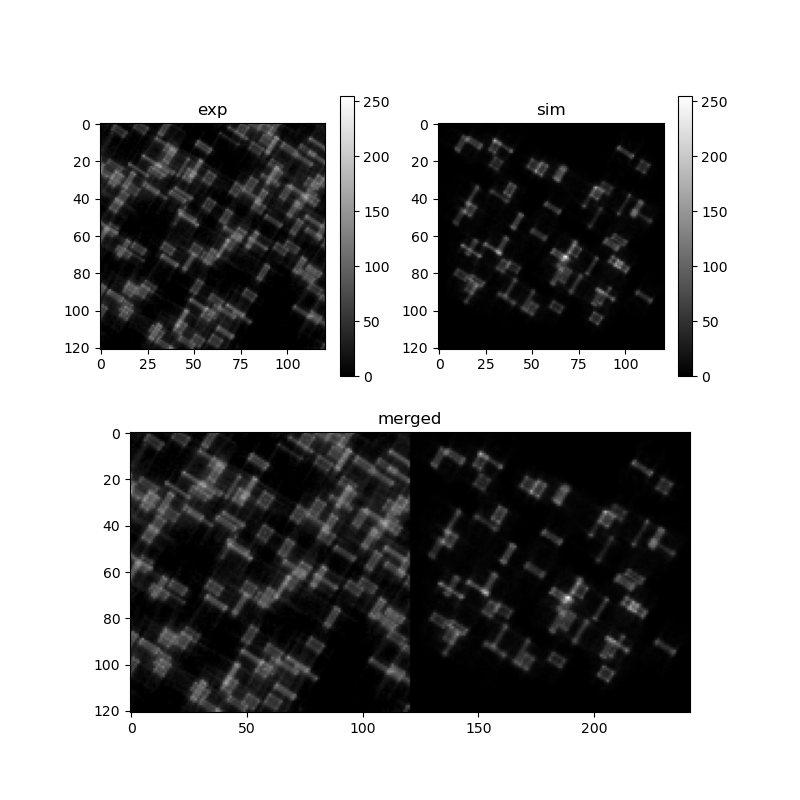

In [11]:
# check SNR by comparing to an experimental image
model = LensModelTraining(param_dict)

sampling = Sampling(param_dict)
xyzps, _, _ = sampling.xyzp_batch()
im1_td = model(torch.from_numpy(xyzps).to(device))
hh = min([im1_td.shape[0], im_1.shape[0]])
ww = min([im1_td.shape[1], im_1.shape[1]])
r0, c0 = np.random.randint(im_1.shape[0]-hh), np.random.randint(im_1.shape[1]-ww)
im_1_cropped = im_1[r0:r0+hh, c0:c0+ww]

plt.close()
plt.figure(figsize=(8, 8))
plt.subplot(221)
plt.title('exp')
plt.imshow(im_1_cropped, cmap='gray', vmin=0, vmax=255)
plt.colorbar()

plt.subplot(222)
plt.title('sim')
plt.imshow(im1_td, cmap='gray', vmin=0, vmax=255)
plt.colorbar()

plt.subplot(212)
plt.title('merged')
plt.imshow(np.concatenate((im_1_cropped, im1_td), axis=1), cmap='gray')
plt.show()

# io.imsave('im.tif', im1_td)

In [34]:
# generate training images
np.random.seed(66)
torch.manual_seed(88)

td_folder = param_dict['td_folder']
if os.path.exists(td_folder):  # delete the directory if it exists
    shutil.rmtree(td_folder)
    
x_folder = os.path.join(td_folder, "x")
os.makedirs(x_folder)  # make the folder for training data

t0 = time.time()
# labels_dict for training
labels_dict = {}
labels_dict['volume_size'] = (param_dict['D'], param_dict['HH'], param_dict['WW'])
labels_dict['us_factor'] = param_dict['us_factor']
labels_dict['blob_r'] = sampling.blob_r  # radius of each 3D blob representing an emitter in space
labels_dict['blob_maxv'] = sampling.blob_maxv  # maximum value of blobs

ntrain = param_dict['n_ims']
for i in range(ntrain):
    xyzps, xyz_ids, blob3d = sampling.xyzp_batch()
    im = model(torch.from_numpy(xyzps).to(device))
    if param_dict['project_01']:
        im = ((im-im.min())/(im.max()-im.min()))

    x_name = str(i).zfill(5) + '.tif'
    io.imsave(os.path.join(x_folder, x_name), im, check_contrast=False)
    labels_dict[x_name] = (xyz_ids, blob3d)

    if i % (ntrain//10) == 0:
        print('Training Example [%d / %d]' % (i + 1, ntrain))
print('Training Example [%d / %d]' % (ntrain, ntrain))

y_file = os.path.join(td_folder, "y.pickle")
with open(y_file, 'wb') as handle:
    pickle.dump(labels_dict, handle, protocol=pickle.HIGHEST_PROTOCOL)


param_file = os.path.join(td_folder, "param.pickle")
with open(param_file, 'wb') as handle:
    pickle.dump(param_dict, handle, protocol=pickle.HIGHEST_PROTOCOL)


t1 = time.time()
print(f'finished generating training data in {t1-t0}s.')

Training Example [1 / 10000]
Training Example [1001 / 10000]
Training Example [2001 / 10000]
Training Example [3001 / 10000]
Training Example [4001 / 10000]
Training Example [5001 / 10000]
Training Example [6001 / 10000]
Training Example [7001 / 10000]
Training Example [8001 / 10000]
Training Example [9001 / 10000]
Training Example [10000 / 10000]
finished generating training data in 344.20429730415344s.


# training

In [35]:
###!!!!!! specify training parameters
batch_size = 16
lr = 0.0005
###!!!!!!

In [36]:
# training
td_folder = param_dict['td_folder']
time_now = datetime.today().strftime('%m-%d_%H-%M')
path_save = os.path.join(param_dict['training_result_path'], os.path.basename(td_folder)+'_'+time_now)
os.makedirs(path_save, exist_ok=True)

print(f'training result folder: {path_save}')

param_file = os.path.join(path_save, "param.pickle")    
with open(param_file, 'wb') as handle:
    pickle.dump(param_dict, handle, protocol=pickle.HIGHEST_PROTOCOL)
params_train = {'batch_size': batch_size, 'shuffle': True}
params_validate = {'batch_size': batch_size, 'shuffle': True}

x_folder = os.path.join(td_folder, 'x')
x_list = os.listdir(x_folder)
num_x = len(x_list)
with open(os.path.join(td_folder, 'y.pickle'), 'rb') as handle:
    labels = pickle.load(handle)

partition = {'train': x_list[:int(num_x*0.9)], 'validate': x_list[int(num_x*0.9):]}
train_ds = MyDataset(x_folder, partition['train'], labels)
train_dl = DataLoader(train_ds, **params_train)
validate_ds = MyDataset(x_folder, partition['validate'], labels)
validate_dl = DataLoader(validate_ds, **params_validate)

D, us_factor, maxv = labels['volume_size'][0], labels['us_factor'], labels['blob_maxv']
model = Net(D=D, us_factor=us_factor, maxv=maxv).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'# of trainable parameters: {n_params}')

optimizer = Adam(list(model.parameters()), lr=lr)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=1, verbose=True, min_lr=1e-6)  # verbose True
# my_loss_func = torch.nn.MSELoss()
my_loss_func = KDE_loss3D(sigma=1.0, device=device)
trainer = TorchTrainer(model, my_loss_func, optimizer, lr_scheduler=scheduler, device=device)

net_file = 'net.pt'
checkpoints = dict(file_name=os.path.join(path_save, net_file),
                   net=Net(D=D, us_factor=us_factor, maxv=maxv),
                   state_dict=None,
                   note=' '
                   )
torch.backends.cudnn.benchmark = True
t0 = time.time()
fit_results = trainer.fit(train_dl, validate_dl, num_epochs=50, checkpoints=checkpoints, early_stopping=4)
t1 = time.time()
fit_file = 'fit.pickle'
with open(os.path.join(path_save, fit_file), 'wb') as handle:
    pickle.dump(fit_results, handle)
    
print(f'finished training in {t1-t0}s.')

training result folder: /home/dafei/ptv/training_results/tank_tp16_01-26_10-07
# of trainable parameters: 582283
--- EPOCH 1/50 ---
(Avg. Loss 77.1777): 100%|███████████████████████████| 63/63 [01:17<00:00,  1.23s/it]

*** Saved checkpoint /home/dafei/ptv/training_results/tank_tp16_01-26_10-07/net.pt
--- EPOCH 2/50 ---
(Avg. Loss 52.5291): 100%|███████████████████████████| 63/63 [01:17<00:00,  1.22s/it]

*** Saved checkpoint /home/dafei/ptv/training_results/tank_tp16_01-26_10-07/net.pt
--- EPOCH 3/50 ---
(Avg. Loss 44.1020): 100%|███████████████████████████| 63/63 [01:17<00:00,  1.22s/it]

*** Saved checkpoint /home/dafei/ptv/training_results/tank_tp16_01-26_10-07/net.pt
--- EPOCH 4/50 ---
(Avg. Loss 39.8829): 100%|███████████████████████████| 63/63 [01:16<00:00,  1.22s/it]

*** Saved checkpoint /home/dafei/ptv/training_results/tank_tp16_01-26_10-07/net.pt
--- EPOCH 5/50 ---
(Avg. Loss 37.2170): 100%|███████████████████████████| 63/63 [01:15<00:00,  1.20s/it]

*** Saved checkpoint /hom